In [14]:
library(ggplot2)



In [18]:
FILE <- "/home/benjamin/Projects/santa_cruz_waves/data/raw/46236.data_spec"

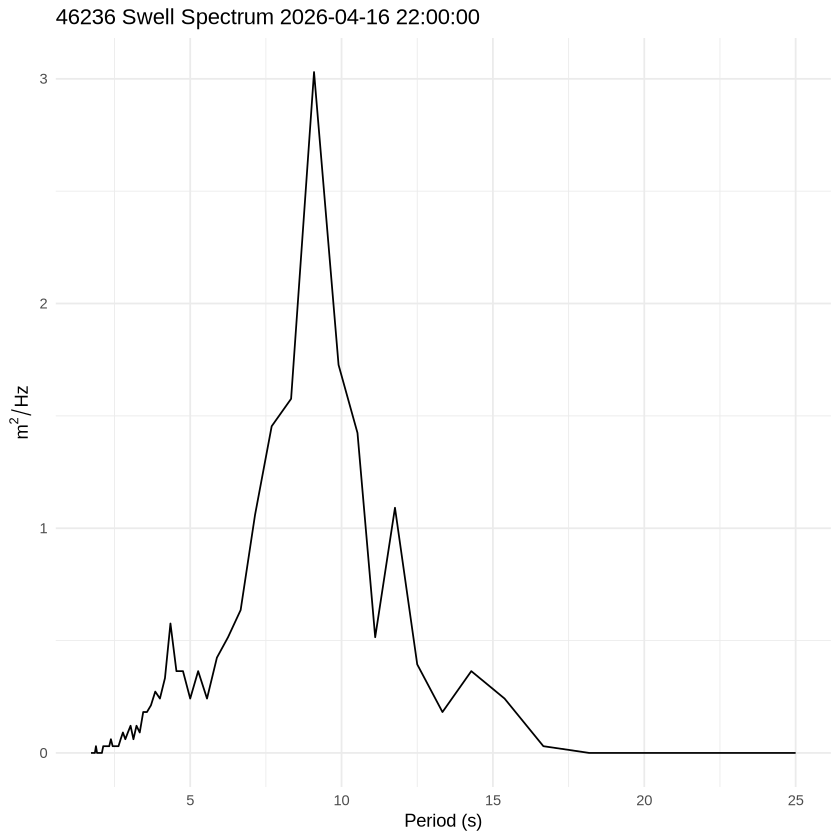

In [22]:

library(ggplot2)

lines <- readLines(FILE)

# keep only data rows
data_lines <- lines[!grepl("^#", lines)]

# most recent snapshot = first data row
latest_line <- data_lines[1]

parts <- scan(text = latest_line, what = character(), quiet = TRUE)

# first 6 fields: YYYY MM DD hh mm Sep_Freq
yr <- as.integer(parts[1])
mo <- as.integer(parts[2])
dy <- as.integer(parts[3])
hr <- as.integer(parts[4])
mi <- as.integer(parts[5])
sep_freq <- as.numeric(parts[6])

# build UTC timestamp
timestamp_utc <- as.POSIXct(
  sprintf("%04d-%02d-%02d %02d:%02d", yr, mo, dy, hr, mi),
  format = "%Y-%m-%d %H:%M",
  tz = "UTC"
)

# remaining fields alternate: energy, frequency label
spec_parts <- parts[-(1:6)]

energy_vals <- spec_parts[seq(1, length(spec_parts), by = 2)]
freq_labels <- spec_parts[seq(2, length(spec_parts), by = 2)]

energy <- as.numeric(energy_vals)
freq_hz <- as.numeric(gsub("[()]", "", freq_labels))

df <- data.frame(
  timestamp_utc = timestamp_utc,
  frequency_hz = freq_hz,
  period_s = 1 / freq_hz,
  energy = energy
)

df <- df[df$period_s <= 25, ]

df <- df[
  is.finite(df$frequency_hz) &
    is.finite(df$period_s) &
    is.finite(df$energy),
]

p <- ggplot(df, aes(x = period_s, y = energy)) +
  geom_line() +
  labs(
    title = paste("46236 Swell Spectrum", format(timestamp_utc, tz = "UTC")),
    x = "Period (s)",
    y = expression(m^2/Hz)
  ) +
  theme_minimal()

print(p)

# for each peak I want to show a representative direction and power

# smooth, local peaks?
# gaussian mixture?

In [26]:
library(pracma)

get_swell_peaks <- function(df, smooth_k = 3, min_peak_frac = 0.12) {
  df <- df[order(df$period_s), ]

  # simple moving average smoothing
  smooth_vals <- stats::filter(df$energy, rep(1 / smooth_k, smooth_k), sides = 2)
  df$energy_smooth <- as.numeric(smooth_vals)

  # edge fallback: use raw values where smoothing produced NA
  na_idx <- is.na(df$energy_smooth)
  df$energy_smooth[na_idx] <- df$energy[na_idx]

  peaks <- findpeaks(
    df$energy_smooth,
    nups = 1,
    ndowns = 1,
    minpeakheight = max(df$energy_smooth, na.rm = TRUE) * min_peak_frac
  )

  if (is.null(peaks)) {
    peak_df <- data.frame(period_s = numeric(), energy_smooth = numeric())
  } else {
    peak_idx <- peaks[, 2]
    peak_df <- df[peak_idx, c("period_s", "energy", "energy_smooth")]
    peak_df <- peak_df[order(-peak_df$energy_smooth), ]
  }

  list(df = df, peaks = peak_df)
}



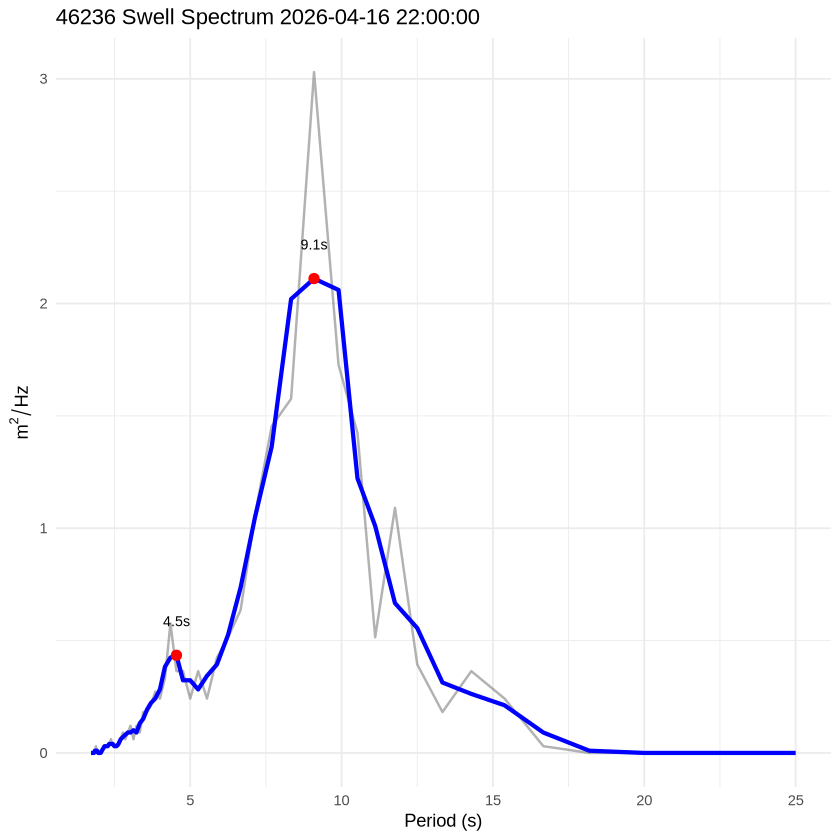

In [28]:
res <- get_swell_peaks(df)

df_plot <- res$df
peak_df <- res$peaks

p <- ggplot(df_plot, aes(x = period_s)) +
  geom_line(aes(y = energy), linewidth = 0.7, alpha = 0.5, color = "gray40") +
  geom_line(aes(y = energy_smooth), linewidth = 1.2, color = "blue") +
  geom_point(
    data = peak_df,
    aes(y = energy_smooth),
    size = 2.5,
    color = "red"
  ) +
  geom_text(
    data = peak_df,
    aes(y = energy_smooth, label = sprintf("%.1fs", period_s)),
    nudge_y = 0.05 * max(df_plot$energy, na.rm = TRUE),
    size = 3
  ) +
  labs(
    title = paste("46236 Swell Spectrum", format(timestamp_utc, tz = "UTC")),
    x = "Period (s)",
    y = expression(m^2/Hz)
  ) +
  theme_minimal()

print(p)